## PLUTO – Test Problems

In this notebook, we verify that the code installation works as intended and get familiar with the analysis of PLUTO simulation results.

### 0. Preamble

In [1]:
%%capture

%config InlineBackend.figure_formats = ['retina']

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import pyPLUTO as pp

import io
import base64

from PIL import Image
from IPython.display import Image as HTML, display
import IPython.display as ipd

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.patches import Wedge

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["steelblue", "olivedrab", "goldenrod", "firebrick", "rebeccapurple"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

plt.plot()
plt.close()

### 1. Simple Shock Tube

A standard hydrodynamics benchmark problem in one dimension with open boundaries, where density and pressure have a sharp discontinuity in their initial conditions:

$$\begin{align*}
\begin{pmatrix}\rho \\ p \\ v\end{pmatrix} = \begin{pmatrix}1 \\ 1 \\ 0\end{pmatrix} && x \leq 0.5 &&&&&&&&
\begin{pmatrix}\rho \\ p \\ v\end{pmatrix} = \begin{pmatrix}1/8 \\ 1/10 \\ 0\end{pmatrix} && x > 0.5
\end{align*}$$

The panels below exhibit a rarefaction wave moving leftward, as well as a discontinuity and shock wave propagating to the right. Default settings were used for the simulator setup step.

In [2]:
path = 'HD/Sod/'
D_last = pp.Load(nout='last', path=path)

outlist = list(D_last.outlist)
outlist = [outlist[0]] * 3 + outlist + [outlist[-1]] * 3

frames = []

for i in outlist:
    D = pp.Load(nout=i, path=path)
    fig, axs = plt.subplots(3, 1, figsize=[6, 12], sharex=True)

    axs[0].plot(D.x1, D.rho, 'k-', ms=3, lw=1.5)
    axs[0].set_ylabel(r'$\rho$')
    axs[0].set_ylim(0, 1.1)
    axs[0].text(1.0125, 0.5, 'Density', rotation=-90, va='center', ha='left', transform=axs[0].transAxes)

    axs[1].plot(D.x1, D.prs, 'k-', ms=3, lw=1.5)
    axs[1].set_ylabel(r'$p$')
    axs[1].set_ylim(0, 1.1)
    axs[1].text(1.0125, 0.5, 'Pressure', rotation=-90, va='center', ha='left', transform=axs[1].transAxes)

    axs[2].plot(D.x1, D.vx1, 'k-', ms=3, lw=1.5)
    axs[2].set_ylabel(r'$v$')
    axs[2].set_ylim(-0.1, 1.1)
    axs[2].text(1.0125, 0.5, 'Velocity', rotation=-90, va='center', ha='left', transform=axs[2].transAxes)

    axs[-1].set_xlabel(r'$x$')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200)
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(Image.open(buf).convert('RGB'))

gif_path = f'{path}/Storage/panel.gif'
frames[0].save(gif_path, format='GIF', save_all=True, append_images=frames[1:], duration=150, loop=0)
ipd.display(ipd.HTML(f'<img src="{gif_path}" width="600">'))

### 2. Orszag Tang Vortex

A simple and reproducible system with a double periodic fluid configuration in two dimensions. Initial conditions are set as follows:

$$\begin{align*}
v = \begin{pmatrix}-\sin y \\ \sin x \end{pmatrix} &&&&
B = \begin{pmatrix}-\sin y \\ \sin 2x \end{pmatrix} &&&&
\rho = 25/9 &&&& p = 5/3
\end{align*}$$

This setup leads to the formation of current sheets and supersonic magnetohydrodynamical turbulence.

#### 2.1 Density

In [3]:
path = 'MHD/Orszag_Tang/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)

rho_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    rho_frames[i] = Di.rho.copy()

vmin = min(r.min() for r in rho_frames.values())
vmax = max(r.max() for r in rho_frames.values())

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    D = pp.Load(nout=i, path=path)

    fig, ax = plt.subplots(figsize=[6, 6])
    im = ax.pcolormesh(D.x1, D.x2, rho_frames[i].T, cmap='plasma', norm=Normalize(vmin=vmin, vmax=vmax), shading='auto')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_aspect('equal')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$\rho$')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/density.gif'
frames[0].save(gif_path, format='GIF', save_all=True, append_images=frames[1:], duration=150, loop=0)
ipd.display(ipd.HTML(f'<img src="{gif_path}" width="600">'))

#### 2.2 Velocity Magnitude

$$|v| = \sqrt{v_x^2 + v_y^2}$$

In [4]:
path = 'MHD/Orszag_Tang/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)

vmag_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    vmag_frames[i] = np.sqrt(Di.vx1**2 + Di.vx2**2)

vmin = min(v.min() for v in vmag_frames.values())
vmax = max(v.max() for v in vmag_frames.values())

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    D = pp.Load(nout=i, path=path)
    fig, ax = plt.subplots(figsize=[6, 6])
    im = ax.pcolormesh(D.x1, D.x2, vmag_frames[i].T, cmap='plasma', norm=Normalize(vmin=vmin, vmax=vmax), shading='auto')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_aspect('equal')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$|v|$')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/velocity.gif'
frames[0].save(gif_path, format='GIF', save_all=True, append_images=frames[1:], duration=150, loop=0)
ipd.display(ipd.HTML(f'<img src="{gif_path}" width="600">'))

#### 2.3 Magnetic Field Magnitude

$$|B| = \sqrt{B_x^2 + B_y^2}$$

In [5]:
path = 'MHD/Orszag_Tang/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)

bmag_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    bmag_frames[i] = np.sqrt(Di.Bx1**2 + Di.Bx2**2)

vmin = min(b.min() for b in bmag_frames.values())
vmax = max(b.max() for b in bmag_frames.values())

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    D = pp.Load(nout=i, path=path)
    fig, ax = plt.subplots(figsize=[6, 6])
    im = ax.pcolormesh(D.x1, D.x2, bmag_frames[i].T, cmap='plasma', norm=Normalize(vmin=vmin, vmax=vmax), shading='auto')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_aspect('equal')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$|B|$')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/field.gif'
frames[0].save(gif_path, format='GIF', save_all=True, append_images=frames[1:], duration=150, loop=0)
ipd.display(ipd.HTML(f'<img src="{gif_path}" width="600">'))

#### 2.4 Current Density

$$J_z = \partial_x B_y - \partial_y B_x$$

In [6]:
path = 'MHD/Orszag_Tang/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)

jz_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    dBy_dx = np.gradient(Di.Bx2, Di.x1, axis=0)
    dBx_dy = np.gradient(Di.Bx1, Di.x2, axis=1)
    jz_frames[i] = dBy_dx - dBx_dy

absmax = max(np.abs(j).max() for j in jz_frames.values())
vmin, vmax = -absmax, absmax

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    D = pp.Load(nout=i, path=path)
    fig, ax = plt.subplots(figsize=[6, 6])
    im = ax.pcolormesh(D.x1, D.x2, jz_frames[i].T, cmap='RdBu_r', norm=Normalize(vmin=vmin, vmax=vmax), shading='auto')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_aspect('equal')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$J_z$', extend='neither')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/current.gif'
frames[0].save(gif_path, format='GIF', save_all=True, append_images=frames[1:], duration=150, loop=0)
ipd.display(ipd.HTML(f'<img src="{gif_path}" width="600">'))

In [7]:
path = 'Custom/Star_Disk/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)
times = D_last.timelist / 62.8318

# Pre-compute polar-to-Cartesian grid
R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
X = R * np.sin(Theta)
Z = R * np.cos(Theta)

# 1. Create spatial mask for region of interest
mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

# 2. Filter data by assigning NaN to points outside the spatial bounds
rho_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    rho_frames[i] = np.where(mask, Di.rho, np.nan)

# 3. Compute vmin and vmax strictly within the ROI (ignoring NaNs)
vmin = np.nanmin([np.nanmin(r) for r in rho_frames.values()])
vmax = np.nanmax([np.nanmax(r) for r in rho_frames.values()])

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    fig, ax = plt.subplots(figsize=[6, 8])
    ax.set_facecolor('k')  # Black background for masked NaN areas

    im = ax.pcolormesh(
        X, Z, rho_frames[i], 
        cmap='magma', 
        norm=LogNorm(vmin=vmin, vmax=vmax), 
        shading='auto'
    )
    
    viertelkreis = Wedge((0, 0), 1.0, 0, 90, color='w')
    ax.add_patch(viertelkreis)

    ax.set_xlabel('R')
    ax.set_ylabel('z')
    ax.set_aspect('equal')

    # Zoom camera specifically to ROI
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 10)

    ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
    ax.legend(loc='upper right', labelcolor='w')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$\rho$')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/density.gif'
frames[0].save(
    gif_path,
    format='GIF',
    save_all=True,
    append_images=frames[1:],
    duration=150,
    loop=0
)

ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [8]:
path = 'Custom/Star_Disk_Modified/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)
times = D_last.timelist / 62.8318

# Pre-compute polar-to-Cartesian grid
R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
X = R * np.sin(Theta)
Z = R * np.cos(Theta)

# 1. Create spatial mask for region of interest
mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

# 2. Filter data by assigning NaN to points outside the spatial bounds
rho_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    rho_frames[i] = np.where(mask, Di.rho, np.nan)

# 3. Compute vmin and vmax strictly within the ROI (ignoring NaNs)
vmin = np.nanmin([np.nanmin(r) for r in rho_frames.values()])
vmax = np.nanmax([np.nanmax(r) for r in rho_frames.values()])

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    fig, ax = plt.subplots(figsize=[6, 8])
    ax.set_facecolor('k')  # Black background for masked NaN areas

    im = ax.pcolormesh(
        X, Z, rho_frames[i], 
        cmap='magma', 
        norm=LogNorm(vmin=vmin, vmax=vmax), 
        shading='auto'
    )
    
    viertelkreis = Wedge((0, 0), 1.0, 0, 90, color='w')
    ax.add_patch(viertelkreis)

    ax.set_xlabel('R')
    ax.set_ylabel('z')
    ax.set_aspect('equal')

    # Zoom camera specifically to ROI
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 10)

    ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
    ax.legend(loc='upper right', labelcolor='w')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$\rho$')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/density.gif'
frames[0].save(
    gif_path,
    format='GIF',
    save_all=True,
    append_images=frames[1:],
    duration=150,
    loop=0
)

ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [9]:
path = 'Custom/Star_Disk/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)
times = D_last.timelist / 62.8318

# Pre-compute polar-to-Cartesian grid
R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
X = R * np.sin(Theta)
Z = R * np.cos(Theta)

# 1. Create spatial mask for region of interest
mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

# 2. Filter data by assigning NaN to points outside the spatial bounds
rho_frames = {}
vx_frames = {}
vz_frames = {}
vr_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    rho_frames[i] = np.where(mask, Di.rho, np.nan)

    # Convert (v1, v2) = (vr, vtheta) to Cartesian (vx, vz)
    vr = Di.vx1
    vth = Di.vx2
    vx = vr * np.sin(Theta) + vth * np.cos(Theta)
    vz = vr * np.cos(Theta) - vth * np.sin(Theta)

    vx_frames[i] = np.where(mask, vx, np.nan)
    vz_frames[i] = np.where(mask, vz, np.nan)
    vr_frames[i] = np.where(mask, vr, np.nan)  # radial component drives arrow color

# 3. Compute vmin and vmax strictly within the ROI (ignoring NaNs)
vmin = np.nanmin([np.nanmin(r) for r in rho_frames.values()])
vmax = np.nanmax([np.nanmax(r) for r in rho_frames.values()])

# Subsample stride for quiver (avoid overplotting arrows on the full grid)
stride1, stride2 = 2, 2  # tune these — larger = sparser arrows

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    fig, ax = plt.subplots(figsize=[6, 8])
    ax.set_facecolor('k')  # Black background for masked NaN areas
    im = ax.pcolormesh(
        X, Z, rho_frames[i],
        cmap='gray',
        norm=LogNorm(vmin=vmin, vmax=vmax),
        shading='auto'
    )
    # Quiver: subsample the grid, color by sign of radial velocity
    Xq = X[::stride1, ::stride2]
    Zq = Z[::stride1, ::stride2]
    Uq = vx_frames[i][::stride1, ::stride2]
    Wq = vz_frames[i][::stride1, ::stride2]
    Vrq = vr_frames[i][::stride1, ::stride2]

    colors = np.where(Vrq >= 0, 'red', 'blue').ravel()

    ax.quiver(
        Xq, Zq, Uq, Wq,
        color=colors,
        scale_units='xy',
        angles='xy',
    )
    viertelkreis = Wedge((0, 0), 1.0, 0, 90, color='w')
    ax.add_patch(viertelkreis)
    ax.set_xlabel('R')
    ax.set_ylabel('z')
    ax.set_aspect('equal')
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 10)
    ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
    ax.legend(loc='upper right', labelcolor='w')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$\rho$')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/velocity.gif'
frames[0].save(
    gif_path,
    format='GIF',
    save_all=True,
    append_images=frames[1:],
    duration=150,
    loop=0
)

ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [10]:
path = 'Custom/Star_Disk_Modified/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)
times = D_last.timelist / 62.8318

# Pre-compute polar-to-Cartesian grid
R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
X = R * np.sin(Theta)
Z = R * np.cos(Theta)

# 1. Create spatial mask for region of interest
mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

# 2. Filter data by assigning NaN to points outside the spatial bounds
rho_frames = {}
vx_frames = {}
vz_frames = {}
vr_frames = {}
for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    rho_frames[i] = np.where(mask, Di.rho, np.nan)

    # Convert (v1, v2) = (vr, vtheta) to Cartesian (vx, vz)
    vr = Di.vx1
    vth = Di.vx2
    vx = vr * np.sin(Theta) + vth * np.cos(Theta)
    vz = vr * np.cos(Theta) - vth * np.sin(Theta)

    vx_frames[i] = np.where(mask, vx, np.nan)
    vz_frames[i] = np.where(mask, vz, np.nan)
    vr_frames[i] = np.where(mask, vr, np.nan)  # radial component drives arrow color

# 3. Compute vmin and vmax strictly within the ROI (ignoring NaNs)
vmin = np.nanmin([np.nanmin(r) for r in rho_frames.values()])
vmax = np.nanmax([np.nanmax(r) for r in rho_frames.values()])

# Subsample stride for quiver (avoid overplotting arrows on the full grid)
stride1, stride2 = 2, 2  # tune these — larger = sparser arrows

outlist = [unique_outs[0]] * 3 + unique_outs + [unique_outs[-1]] * 3

frames = []
for i in outlist:
    fig, ax = plt.subplots(figsize=[6, 8])
    ax.set_facecolor('k')  # Black background for masked NaN areas
    im = ax.pcolormesh(
        X, Z, rho_frames[i],
        cmap='gray',
        norm=LogNorm(vmin=vmin, vmax=vmax),
        shading='auto'
    )
    # Quiver: subsample the grid, color by sign of radial velocity
    Xq = X[::stride1, ::stride2]
    Zq = Z[::stride1, ::stride2]
    Uq = vx_frames[i][::stride1, ::stride2]
    Wq = vz_frames[i][::stride1, ::stride2]
    Vrq = vr_frames[i][::stride1, ::stride2]

    colors = np.where(Vrq >= 0, 'red', 'blue').ravel()

    ax.quiver(
        Xq, Zq, Uq, Wq,
        color=colors,
        scale_units='xy',
        angles='xy',
    )
    viertelkreis = Wedge((0, 0), 1.0, 0, 90, color='w')
    ax.add_patch(viertelkreis)
    ax.set_xlabel('R')
    ax.set_ylabel('z')
    ax.set_aspect('equal')
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 10)
    ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
    ax.legend(loc='upper right', labelcolor='w')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax, label=r'$\rho$')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    img.load()
    frames.append(img.convert('RGB'))

gif_path = f'{path}/Storage/velocity.gif'
frames[0].save(
    gif_path,
    format='GIF',
    save_all=True,
    append_images=frames[1:],
    duration=150,
    loop=0
)

ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [4]:
def mass_flux(D, r0):
    ir = np.argmin(np.abs(D.x1 - r0))
    rho_r = D.rho[ir, :]
    vr_r = D.vx1[ir, :]
    theta = D.x2

    integrand = rho_r * vr_r * np.sin(theta)
    return 2 * np.pi * r0**2 * np.trapezoid(integrand, theta)


def angmom_flux(D, r0):
    ir = np.argmin(np.abs(D.x1 - r0))
    rho_r = D.rho[ir, :]
    vr_r = D.vx1[ir, :]
    vphi_r = D.vx3[ir, :]
    theta = D.x2

    l_specific = r0 * np.sin(theta) * vphi_r
    integrand = rho_r * vr_r * l_specific * np.sin(theta)
    return 2 * np.pi * r0**2 * np.trapezoid(integrand, theta)


def mass_flux_split(D, r0):
    """Split by disk fraction (tr1), weighted continuously rather than a hard threshold."""
    ir = np.argmin(np.abs(D.x1 - r0))
    rho_r = D.rho[ir, :]
    vr_r = D.vx1[ir, :]
    tr_r = D.tr1[ir, :]
    theta = D.x2

    base = rho_r * vr_r * np.sin(theta)
    Mdot_disk = 2 * np.pi * r0**2 * np.trapezoid(base * tr_r, theta)
    Mdot_corona = 2 * np.pi * r0**2 * np.trapezoid(base * (1 - tr_r), theta)
    return Mdot_disk, Mdot_corona, Mdot_disk + Mdot_corona


def angmom_flux_split(D, r0):
    ir = np.argmin(np.abs(D.x1 - r0))
    rho_r = D.rho[ir, :]
    vr_r = D.vx1[ir, :]
    vphi_r = D.vx3[ir, :]
    tr_r = D.tr1[ir, :]
    theta = D.x2

    l_specific = r0 * np.sin(theta) * vphi_r
    base = rho_r * vr_r * l_specific * np.sin(theta)
    Ldot_disk = 2 * np.pi * r0**2 * np.trapezoid(base * tr_r, theta)
    Ldot_corona = 2 * np.pi * r0**2 * np.trapezoid(base * (1 - tr_r), theta)
    return Ldot_disk, Ldot_corona, Ldot_disk + Ldot_corona

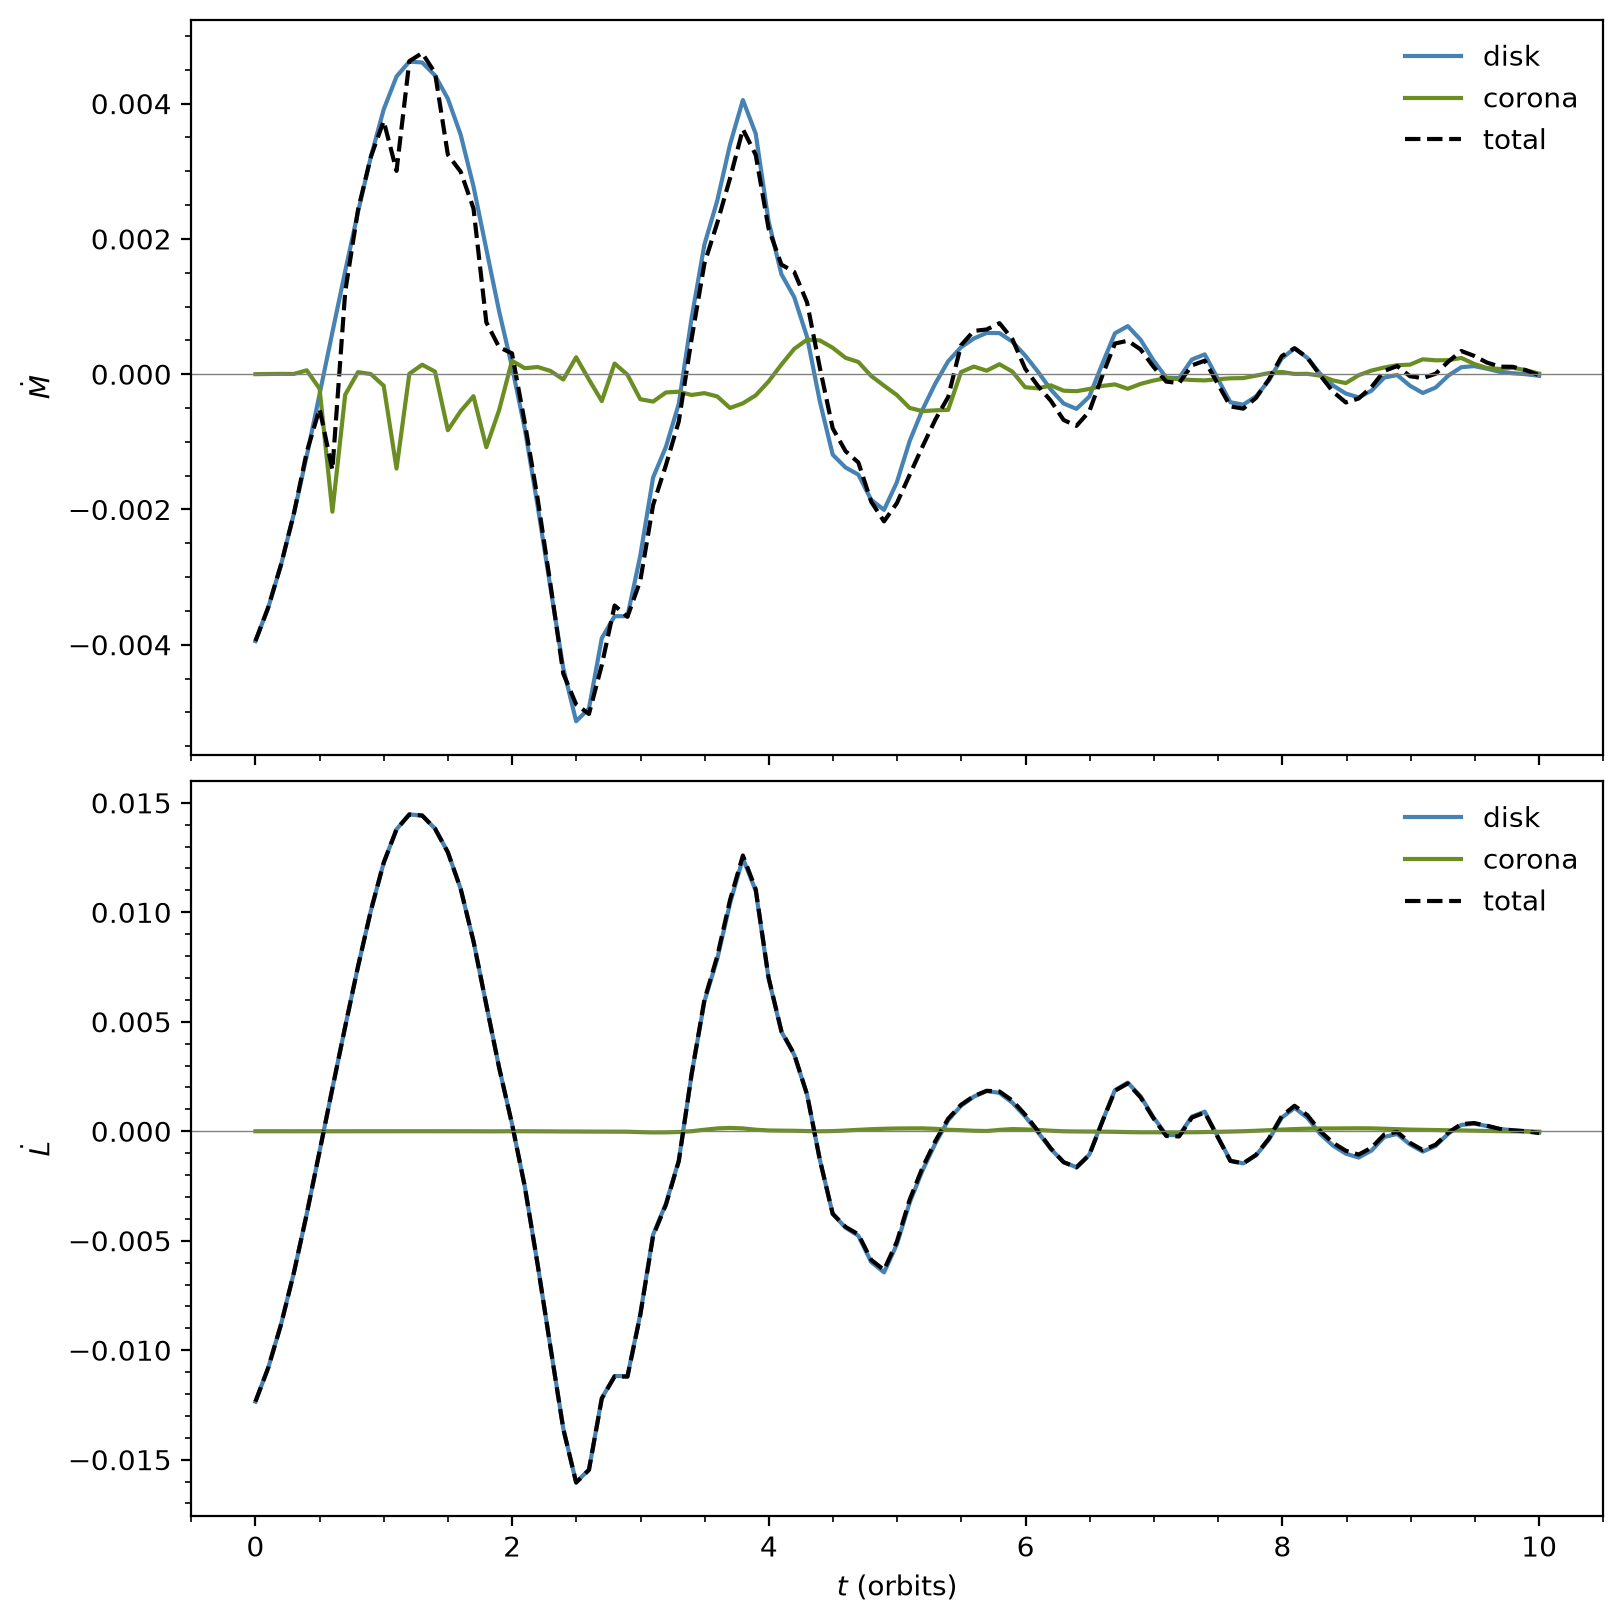

In [9]:
r0 = 10.0

path = 'Custom/Star_Disk/'
D_last = pp.Load(nout='last', path=path)
unique_outs = list(D_last.outlist)
times = D_last.timelist / 62.8318

Mdot_t = {'disk': [], 'corona': [], 'total': []}
Ldot_t = {'disk': [], 'corona': [], 'total': []}

for i in unique_outs:
    Di = pp.Load(nout=i, path=path)
    md, mc, mt = mass_flux_split(Di, r0)
    ld, lc, lt = angmom_flux_split(Di, r0)
    Mdot_t['disk'].append(md); Mdot_t['corona'].append(mc); Mdot_t['total'].append(mt)
    Ldot_t['disk'].append(ld); Ldot_t['corona'].append(lc); Ldot_t['total'].append(lt)

fig, axs = plt.subplots(2, 1, figsize=[8, 8], sharex=True)
axs[0].plot(times, Mdot_t['disk'], label='disk')
axs[0].plot(times, Mdot_t['corona'], label='corona')
axs[0].plot(times, Mdot_t['total'], 'k--', label='total')
axs[0].set_ylabel(r'$\dot{M}$')
axs[0].legend()
axs[0].axhline(0, color='gray', lw=0.5)

axs[1].plot(times, Ldot_t['disk'], label='disk')
axs[1].plot(times, Ldot_t['corona'], label='corona')
axs[1].plot(times, Ldot_t['total'], 'k--', label='total')
axs[1].set_ylabel(r'$\dot{L}$')
axs[1].set_xlabel(r'$t$ (orbits)')
axs[1].legend()
axs[1].axhline(0, color='gray', lw=0.5)

plt.show()